<a href="https://colab.research.google.com/github/Kishoby/Final-Research/blob/HG-Boost/HG_Boost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [2]:
df1 = pd.read_csv("/content/drive/MyDrive/Research/COMURS/04 09 2025 to 06 08 2025.csv")
df2 = pd.read_csv("/content/drive/MyDrive/Research/COMURS/06 09 2025 to 08 08 2025.csv")
df3 = pd.read_csv("/content/drive/MyDrive/Research/COMURS/08 09 2025 to 10 08 2025.csv")

datasets = [df1, df2, df3]


In [3]:
features = [
    "air_quality_us-epa-index",
    "air_quality_gb-defra-index",
    "air_quality_Carbon_Monoxide",
    "air_quality_Nitrogen_dioxide",
    "air_quality_Sulphur_dioxide",
    "air_quality_Ozone",
    "humidity",
    "cloud",
    "visibility_miles",
    "visibility_km",
    "longitude",
    "gust_kph",
    "precip_mm",
    "precip_in"
]


In [4]:
def plot_actual_vs_predicted(y_true, y_pred, iteration):
    plt.figure(figsize=(7,5))
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.plot([y_true.min(), y_true.max()],
             [y_true.min(), y_true.max()],
             'r--')
    plt.xlabel("Actual PM2.5")
    plt.ylabel("Predicted PM2.5")
    plt.title(f"Actual vs Predicted – Iteration {iteration}")
    plt.grid(True)
    plt.show()

def plot_residuals(y_true, y_pred, iteration):
    residuals = y_true - y_pred
    plt.figure(figsize=(7,5))
    plt.scatter(y_pred, residuals, alpha=0.5)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel("Predicted PM2.5")
    plt.ylabel("Residual (Actual - Predicted)")
    plt.title(f"Residual Plot – Iteration {iteration}")
    plt.grid(True)
    plt.show()

def plot_error_distribution(y_true, y_pred, iteration):
    errors = y_true - y_pred
    plt.figure(figsize=(7,5))
    plt.hist(errors, bins=40, alpha=0.7)
    plt.xlabel("Prediction Error")
    plt.title(f"Error Distribution – Iteration {iteration}")
    plt.grid(True)
    plt.show()


In [5]:
model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_depth=10,
    max_iter=500,
    random_state=42
)



========== Iteration 1 ==========
Rows used: 11876
R2 Score: 0.966595306918832
MSE: 41.90442983351413
RMSE: 6.473363100700758
MAE: 2.9426112901086836
MAPE: 24.477475023562597


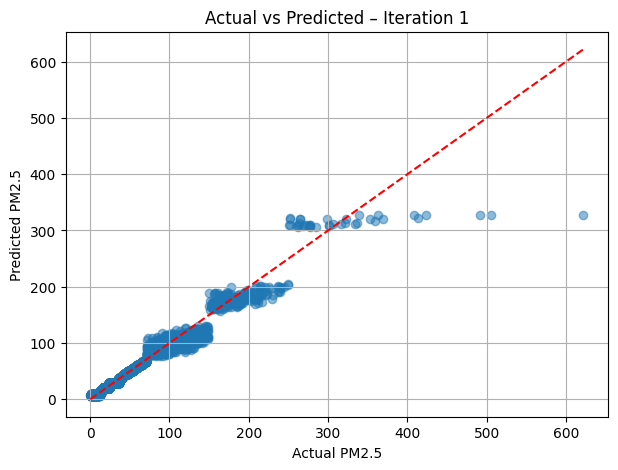

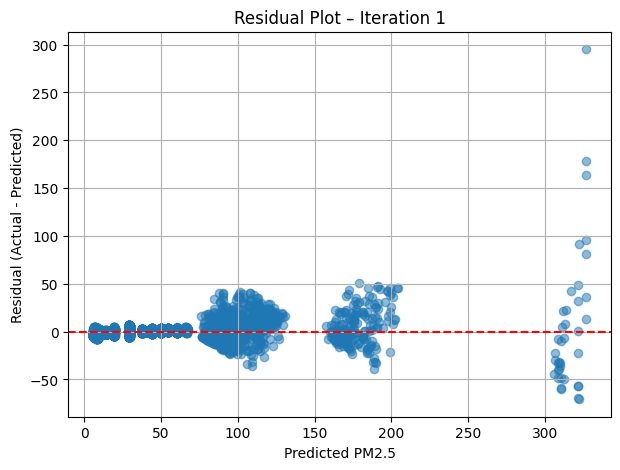

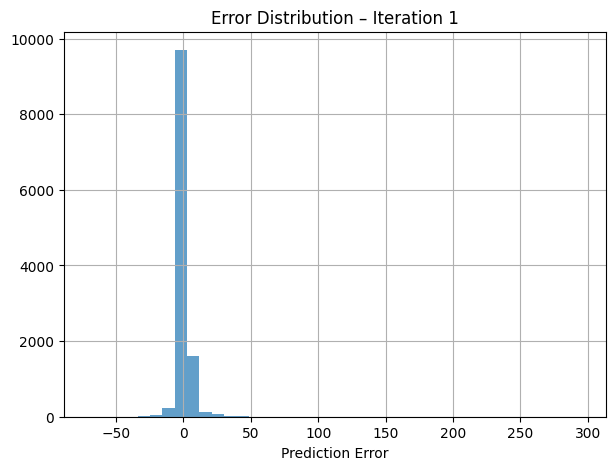


========== Iteration 2 ==========
Rows used: 23770
R2 Score: 0.9787639567834361
MSE: 24.54714074329061
RMSE: 4.954507114061964
MAE: 2.6222695966396383
MAPE: 19.31664802404322


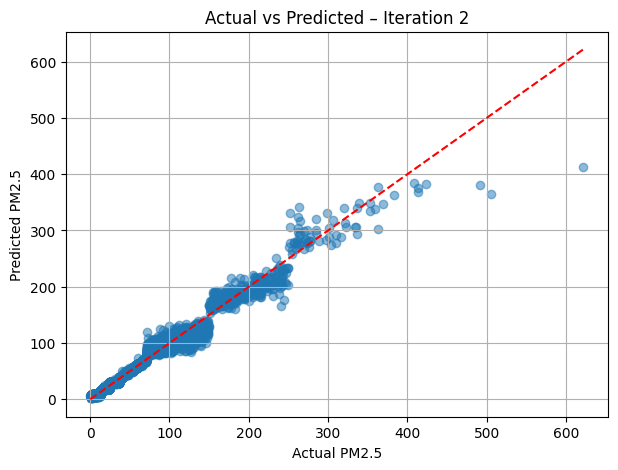

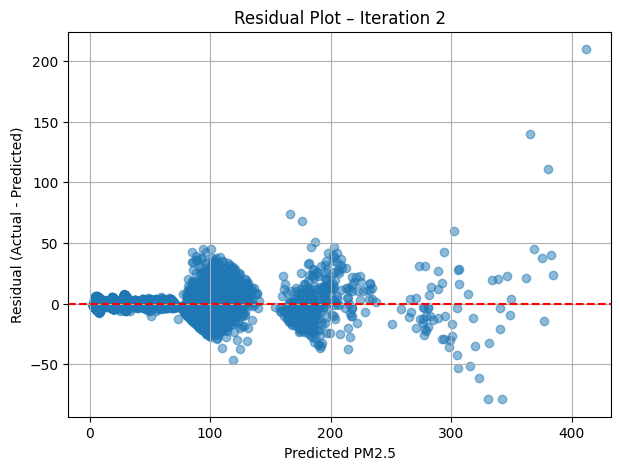

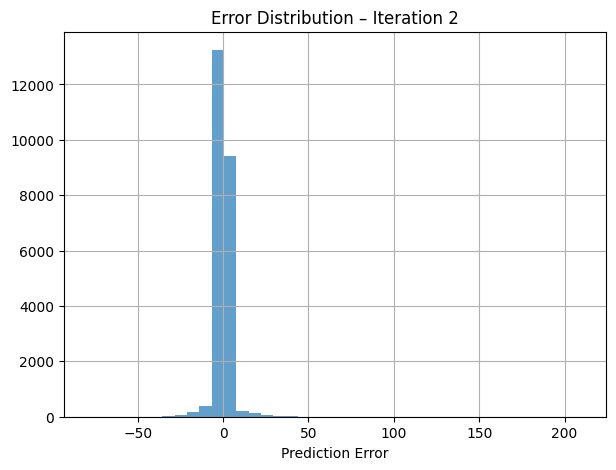


========== Iteration 3 ==========
Rows used: 35660
R2 Score: 0.9771196559558211
MSE: 25.416223339419393
RMSE: 5.041450519386201
MAE: 2.6221302197550886
MAPE: 19.617901423329723


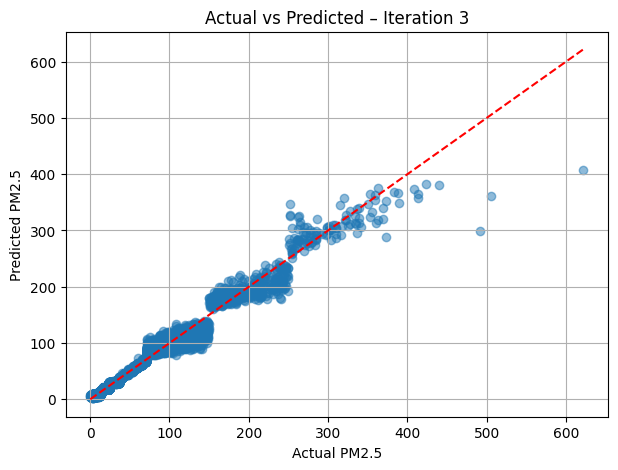

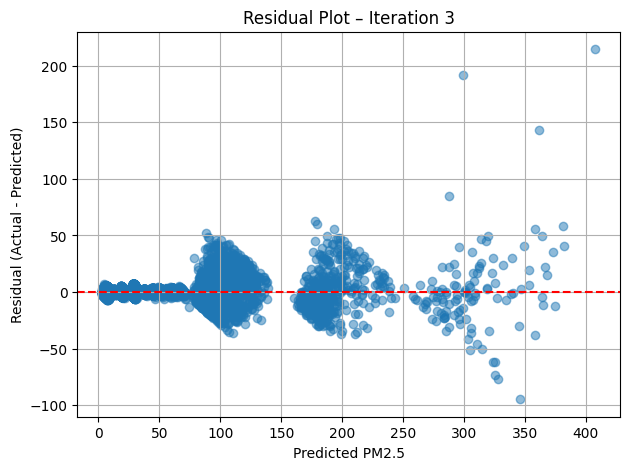

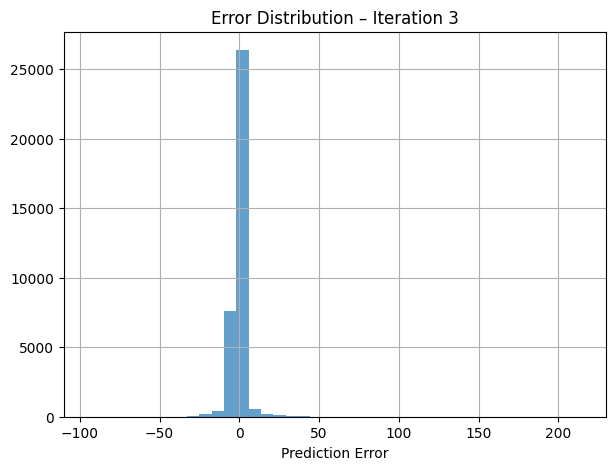

In [6]:
combined_data = pd.DataFrame()   # keeps adding datasets

for i, data in enumerate(datasets):
    iteration = i + 1

    print(f"\n========== Iteration {iteration} ==========")

    # Add this dataset to combined pool
    combined_data = pd.concat([combined_data, data], ignore_index=True)

    X = combined_data[features]
    y = combined_data["air_quality_PM2.5"]

    # Train HGBoost on accumulated data
    model.fit(X, y)

    # Predict on same iteration data
    y_pred = model.predict(X)

    # Metrics
    mse = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y, y_pred)
    mape = np.mean(np.abs((y - y_pred) / y)) * 100
    r2 = r2_score(y, y_pred)

    print(f"Rows used: {X.shape[0]}")
    print(f"R2 Score: {r2}")
    print(f"MSE: {mse}")
    print(f"RMSE: {rmse}")
    print(f"MAE: {mae}")
    print(f"MAPE: {mape}")

    # Plots
    plot_actual_vs_predicted(y, y_pred, iteration)
    plot_residuals(y, y_pred, iteration)
    plot_error_distribution(y, y_pred, iteration)
